In [19]:
# 데이터 불러오기

import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/Colab Notebooks/breast_cancer.csv'
df = pd.read_csv(path)

In [20]:
# 데이터 출력해서 확인
df.head()

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [21]:
#label, feature 데이터 입력하

y=df['label']

X=df.drop('label',axis=1)

In [22]:
y.value_counts()
X.head()

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [23]:
# numpy 변환
X = X.values # 엑셀 형태 → 숫자 배열로 변환하기 위해 사

# 정규화 (데이터를 비슷한 범위로 맞추는 작업)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [25]:
from tensorflow.keras import layers, models
# 층(layer)을 순서대로 쌓는 모델, 입력 → 은닉층 → 출력층으로 일직선 구조

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)), # 첫 번째 층 (입력층 + 은닉층),
    # 뉴런(노드) 64개, 입력 데이터의 컬럼 개수, activation="relu" <- 활성화 함수
    layers.Dropout(0.3), # 30% 뉴런을 랜덤으로 off > 과적합 방지
    layers.Dense(32, activation="relu"),# 두 번째 은닉층, 뉴런을 64 → 32로 줄이면서 중요한 정보만 남김
    layers.Dense(1, activation="sigmoid")
    # Y.shape[1] = 클래스 개수, softmax = 확률로 변환
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
# 컴파일
model.compile(
    optimizer="adam", # 가중치 업데이트 방법, 자동으로 학습률 조정
    loss="binary_crossentropy",
    metrics=["accuracy"] # 정확도 측정
)

In [27]:
# 모델학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2, # 학습 데이터 중 20%를 검증용으로 사용
    epochs=50, # 전체 데이터를 50번 반복 학습
    batch_size=16, # 한 번에 16개씩 학습
    verbose=1 # 학습 과정 출력
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7853 - loss: 0.5155 - val_accuracy: 0.9302 - val_loss: 0.3253
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9588 - loss: 0.2595 - val_accuracy: 0.9884 - val_loss: 0.1772
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9618 - loss: 0.1575 - val_accuracy: 0.9884 - val_loss: 0.1145
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9676 - loss: 0.1267 - val_accuracy: 0.9884 - val_loss: 0.0865
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9765 - loss: 0.0954 - val_accuracy: 0.9884 - val_loss: 0.0723
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9735 - loss: 0.0907 - val_accuracy: 0.9767 - val_loss: 0.0655
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9824 - loss: 0.0740 - val_accuracy: 0.9767 - val_loss: 0.0593
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9824 - loss: 0.0713 - val_accuracy: 0.9767 - val_loss

In [28]:

y_pred = model.predict(X_test) # 결과 = 확률
y_pred_class = (y_pred >= 0.5).astype(int).flatten()
y_test_class = y_test

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [29]:
# 그래프 그리기용 데이터 저장
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']


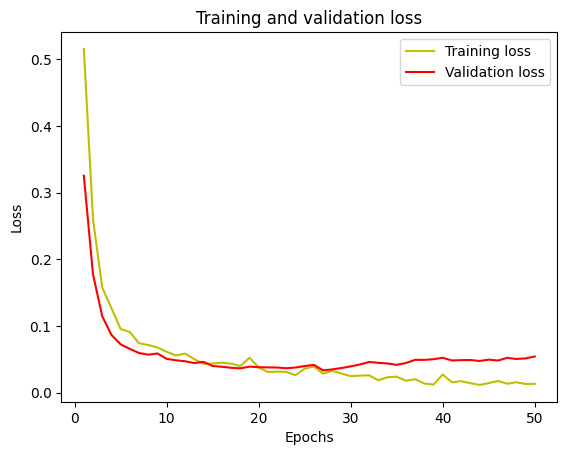

In [30]:
# 학습 과정에서 손실(loss)이 어떻게 변하는지 시각화

import matplotlib.pyplot as plt
import seaborn as sns

loss = history.history['loss'] # loss = 훈련 데이터 오차 /
val_loss = history.history['val_loss'] # val_loss = 검증 데이터 오차
# history는 model.fit() 결과
epochs = range(1, len(loss) + 1) # x축 만들기

plt.plot(epochs, loss, 'y', label='Training loss') # 훈련 데이터 손실
# x축: epoch y축: loss 'y': 노란색
plt.plot(epochs, val_loss, 'r', label='Validation loss') # 검증 데이터 손실
# 'r': 빨간색
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


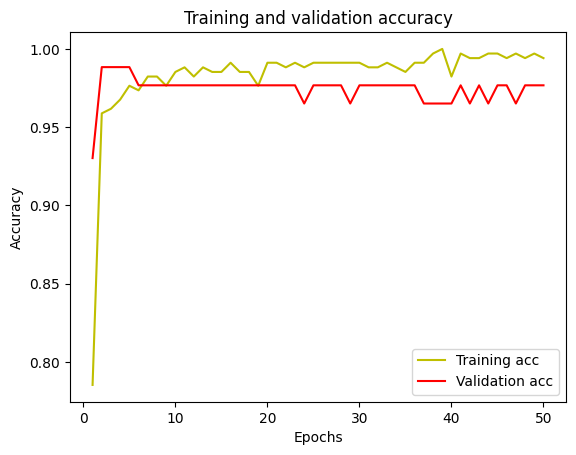

In [31]:
acc = history.history['accuracy'] # 훈련 데이터 정확도
val_acc = history.history['val_accuracy'] # 검증 데이터 정확도
plt.plot(epochs, acc, 'y', label='Training acc') # 훈련 정확도 (노란색)
plt.plot(epochs, val_acc, 'r', label='Validation acc') # 검증 정확도 (빨간색)
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [32]:

from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93        53
           1       0.96      0.97      0.96        90

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143

[[49  4]
 [ 3 87]]
